In [9]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from model import UNet
from utils_noise import *
import pickle
import copy
device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Parameters

In [6]:
store_path = "/Users/aj/Desktop/work/PostDoc_UMCG/work/analysis/EDX_Project/PreHyperspectralEDX/preprocessing_basic/tmp/aligned_hsi/"
patch_size = (64,64)
n_input_frames = 10
n_patches = 200
batch_size = 4
n_epochs = 150
lr = 1e-3
bands = [4,25,28]

In [15]:
dataset[0]

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (10,) (3,) 

In [12]:
# Dataset and DataLoader
dataset = HyperspectralPatchDataset(store_path, patch_size=patch_size, bands=bands, n_input_frames=n_input_frames, n_patches=n_patches)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model
sample_input, _ = dataset[0]
in_ch = sample_input.shape[0]
model = UNet(in_ch, in_ch).to(device)

# Optimizer and Loss
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()

# Training loop
for epoch in range(n_epochs):
    total_loss = 0
    for i, (x, y) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(loader):.6f}")

# Save model
torch.save(model.state_dict(), "noise2noise_hyper.pth")

IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (10,) (3,) 

## Test

In [23]:
# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile = pickle.load(file)

In [24]:
# Example setup
#patch_size = (8, 8)  # same as training

# Load model
in_ch = tile.EDX.shape[2]
model = UNet(in_ch, in_ch).to(device)
model.load_state_dict(torch.load("noise2noise_hyper.pth", map_location=device))
model.eval()

# Pad image if needed to be divisible by patch size
H, W, B = tile.EDX.shape
h_t, w_t = patch_size

pad_h = (h_t - H % h_t) % h_t
pad_w = (w_t - W % w_t) % w_t

padded = np.pad(tile.EDX, ((0,pad_h),(0,pad_w),(0,0)), mode='reflect')
H_p, W_p, _ = padded.shape

# Prepare output array
output = np.zeros_like(padded, dtype=np.float32)

# Sliding over patches
for i in range(0, H_p, h_t):
    for j in range(0, W_p, w_t):
        patch = padded[i:i+h_t, j:j+w_t, :]
        patch_tensor = torch.from_numpy(patch).float().permute(2,0,1).unsqueeze(0).to(device)  # (1, b, h, w)
        
        with torch.no_grad():
            pred = model(patch_tensor)
        
        pred_np = pred.squeeze(0).permute(1,2,0).cpu().numpy()  # back to (h, w, b)
        output[i:i+h_t, j:j+w_t, :] = pred_np

# Remove padding
if pad_h > 0: output = output[:H, :, :]
if pad_w > 0: output = output[:, :W, :]

print("Reconstructed output shape:", output.shape)  # should be (2048, 2048, 250)



Reconstructed output shape: (2048, 2048, 250)


In [25]:
# create a new denoised tile object
tile_denoised = copy.deepcopy(tile)
tile_denoised.EDX = output

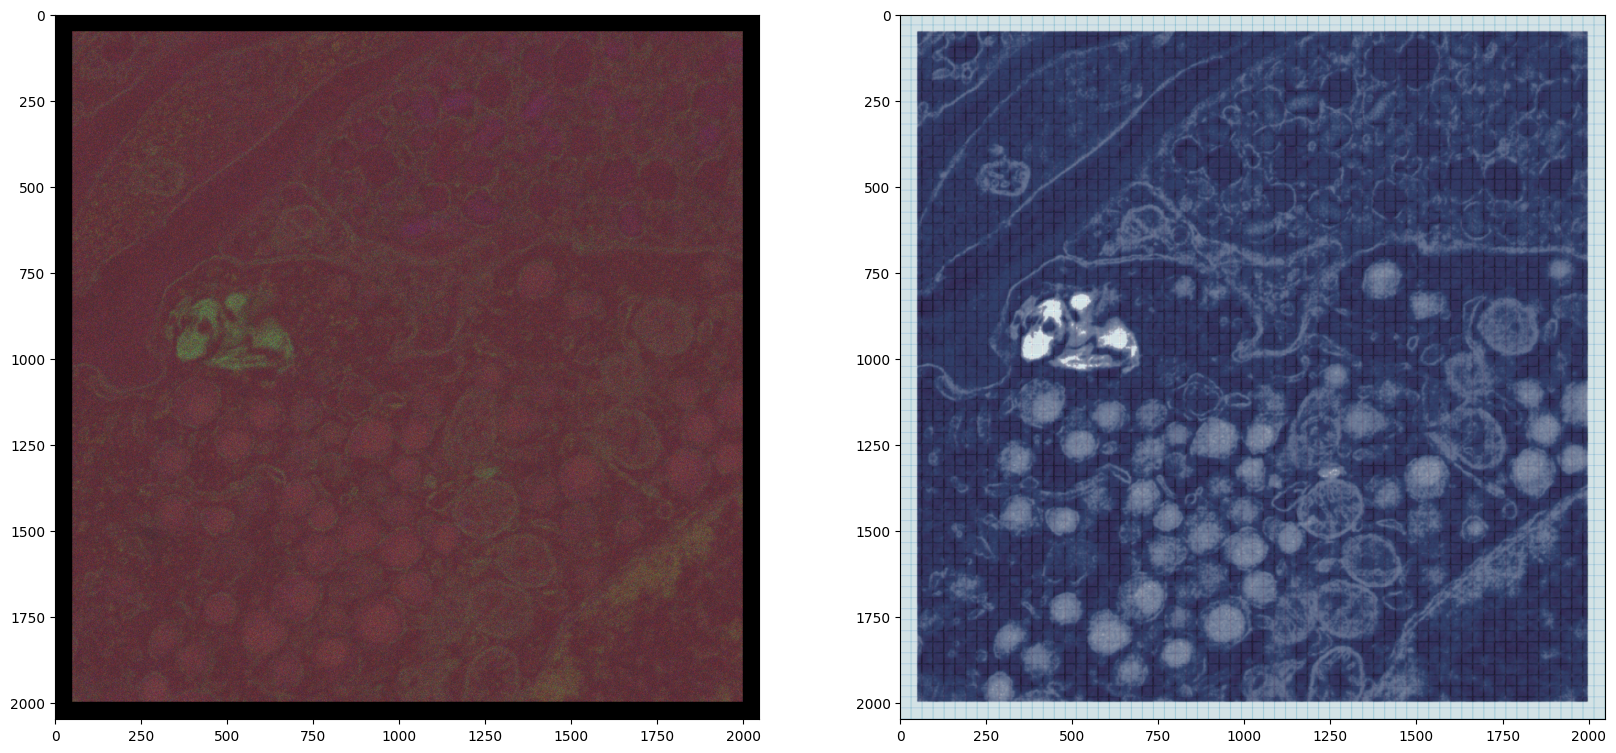

In [30]:
f, ax = plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(tile.FalseColor(bands=[4,25,28]))
ax[1].imshow(tile_denoised.FalseColor(bands=[4,25,28]))